# 스프린트 미션 8 ***(축구 경기 영상 내의 다양한 객체 이미지 분할)***

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.transforms import v2
from PIL import Image

## 데이터 확인 및 전처리
### 데이터 경로

In [ ]:
# 이미지 파일 목록 정의
path = "football"
img_folder = os.path.join(path, "images")
img_list = os.listdir(img_folder)

# 원본이미지 / 마스크 이미지 찾기
image_files = sorted([name for name in img_list if name.endswith(".jpg")])
mask_files = sorted([name for name in img_list if "fuse" in name])

'Frame 1  (1).jpg'

- 이미지 순서쌍 확인

In [3]:
# 이미지 순서쌍 확인
image_pairs = []
for orig_img in image_files:
    # 동일한 프레임의 fuse 파일 
    mask_img = next((name for name in image_files if orig_img in name), None)
    image_pairs.append((orig_img, mask_img))

print(f"{len(image_pairs)} pairs")

100 pairs


### 데이터셋 설정


- 마스크 이미지로부터 색상 추출하는 함수 정의   
색상 추출 후 라벨을 부여하여 모델의 타겟값으로 설정

In [35]:
# 데이터셋 전체의 고유한 색상 수집
def get_unique_colors(img_folder, mask_files, max_classes=11):
    color_set = set()

    for mask_file in mask_files:
        mask_path = os.path.join(img_folder, mask_file)
        mask_pil = Image.open(mask_path).convert("RGB")  # 마스크 이미지를 불러오고
        mask = np.array(mask_pil)                        # np 배열로 바꿔준다음
        mask = mask.reshape(-1,3)                        #  [픽셀수 , 3] => RGB배열은 그대로 두고 픽셀을 아래로 펼쳐라
        unique_colors = np.unique(mask, axis=0)          # 모든 행들을 보고 중복값 제거 후 나열

        for color in unique_colors:
            color_set.add(tuple(color))  # 고유한 색상 저장

            # 클래스 개수가 max_classes개가 되면 중단
            if len(color_set) >= max_classes:
                return list(color_set)  # 최대 max_classes개까지만 반환

    return list(color_set)  # 모든 마스크를 순회 후 반환

# 모든 마스크에서 등장하는 색상 수집
unique_colors = get_unique_colors(img_folder, mask_files)
color_to_label = {color: idx for idx, color in enumerate(unique_colors)}

def mask_rgb_to_label(mask, color_to_label):
    h, w, _ = mask.shape
    label_mask = np.zeros((h, w), dtype=np.int64)

    for color, label in color_to_label.items():
        label_mask[(mask == color).all(axis=-1)] = label

    return label_mask

- 데이터셋 정의  

In [36]:
class FootballDataset(Dataset):
    def __init__(self, image_files, mask_files, image_folder, color_to_label):
        self.image_files = image_files
        self.mask_files = mask_files
        self.image_folder = image_folder
        self.color_to_label = color_to_label
        self.img_transform = v2.Compose([
            v2.Resize((256, 256)),
            v2.ToImage(),
            v2.ToDtype(torch.float32, scale=True)
        ])
      
    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_folder, self.image_files[idx])
        mask_path = os.path.join(self.image_folder, self.mask_files[idx])

        img = Image.open(img_path).convert("RGB")    # 원본 이미지 로드
        img = self.img_transform(img)

        mask = Image.open(mask_path).convert("RGB")  # 마스크 이미지 로드
        mask = np.array(mask.resize((256, 256), resample=Image.Resampling.NEAREST))
        mask = mask_rgb_to_label(mask, self.color_to_label)
        mask = torch.from_numpy(mask).long()     # (H, W) CrossEntrophy 손실 함수에서 타겟 변수는 정수인덱스여야 함. 그래서 정수로 dtype=torch.long

        return img, mask

- 데이터로더 정의

In [37]:
# 데이터 로드
dataset = FootballDataset(image_files, mask_files, img_folder, color_to_label)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, drop_last=False)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, drop_last=False)

print(f"Train Data: {len(train_dataset)}, Test Data: {len(test_dataset)}")

Train Data: 80, Test Data: 20


## 모델 학습

### UNet 모델 정의

In [57]:
class DoubleConv(nn.Module):  #  (convolution => [BN] => ReLU) * 2
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)
    
class Unet(nn.Module):
    def __init__(self, num_classes=11):
        super().__init__()
        self.encoder1 = DoubleConv(3, 64)
        self.encoder2 = DoubleConv(64, 128)
        self.encoder3 = DoubleConv(128, 256)

        self.bottleneck = DoubleConv(256, 512)

        self.pool = nn.MaxPool2d(2)

        self.upsample3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.decoder3 = DoubleConv(512, 256)
        self.upsample2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.decoder2 = DoubleConv(256, 128)
        self.upsample1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.decoder1 = DoubleConv(128, 64)
        
        self.output = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):
        e1 = self.encoder1(x)
        e2 = self.encoder2(self.pool(e1))
        e3 = self.encoder3(self.pool(e2))

        b = self.bottleneck(self.pool(e3))

        d3 = self.upsample3(b)
        d3 = torch.cat((d3, e3), dim=1)
        d3 = self.decoder3(d3)

        d2 = self.upsample2(d3)
        d2 = torch.cat((d2, e2), dim=1)
        d2 = self.decoder2(d2)

        d1 = self.upsample1(d2)
        d1 = torch.cat((d1, e1), dim=1)
        d1 = self.decoder1(d1)

        return self.output(d1)        

### 모델 구동 환경 설정

In [58]:
device = torch.device("cuda" if torch.cuda.is_available else "cpu")
print(device)

cuda


### 모델 학습

In [60]:
model = Unet().to(device)
loss_fn = nn.CrossEntropyLoss()  # 손실함수 -> 다중분류에 적합한 CrossEntrophy
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005) 

epochs = 50


for epoch in range(epochs):
    total_loss_UNet = 0

    model.train()
    for images, mask in train_loader:
        images, mask = images.to(device), mask.to(device)

        output = model(images)
        optimizer.zero_grad()
        loss = loss_fn(output, mask)
        loss.backward()
        optimizer.step()

        total_loss_UNet += loss.item()

    epoch_loss_UNet = total_loss_UNet / len(train_loader)
    print(f"epooch [{epoch+1}/{epochs}] , loss [{epoch_loss_UNet:.4f}]")



epooch [1/50] , loss [1.3946]
epooch [2/50] , loss [0.8799]
epooch [3/50] , loss [0.7597]
epooch [4/50] , loss [0.6508]
epooch [5/50] , loss [0.6395]
epooch [6/50] , loss [0.5506]
epooch [7/50] , loss [0.4412]
epooch [8/50] , loss [0.4139]
epooch [9/50] , loss [0.4026]
epooch [10/50] , loss [0.3378]
epooch [11/50] , loss [0.3219]
epooch [12/50] , loss [0.2680]
epooch [13/50] , loss [0.2589]
epooch [14/50] , loss [0.2964]
epooch [15/50] , loss [0.2461]
epooch [16/50] , loss [0.2319]
epooch [17/50] , loss [0.2211]
epooch [18/50] , loss [0.1989]
epooch [19/50] , loss [0.1938]
epooch [20/50] , loss [0.2010]
epooch [21/50] , loss [0.2482]
epooch [22/50] , loss [0.3174]
epooch [23/50] , loss [0.2661]
epooch [24/50] , loss [0.2298]
epooch [25/50] , loss [0.1730]
epooch [26/50] , loss [0.1539]
epooch [27/50] , loss [0.1538]
epooch [28/50] , loss [0.1464]
epooch [29/50] , loss [0.1500]
epooch [30/50] , loss [0.1739]
epooch [31/50] , loss [0.1487]
epooch [32/50] , loss [0.1722]
epooch [33/50] , 

- loss = 0.0725로 안정적으로 학습된것을 확인  
- 테스트 데이터셋으로 평균 loss와 정확도 판단.

### 모델 검증

In [68]:
import torch

def UNet_test(model, test_loader, loss_fn, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, masks in test_loader:
            imgs  = imgs.to(device)      # (B,3,H,W)
            masks = masks.to(device)     # (B,H,W)

            outputs = model(imgs)        # (B,C,H,W)
            loss = loss_fn(outputs, masks)
            total_loss += loss.item()

            preds = outputs.argmax(dim=1)   # (B,H,W)
            correct += (preds == masks).sum().item()
            total += masks.numel()

    avg_loss = total_loss / len(test_loader)
    pixel_acc = correct / total

    print(f"[Test] loss: {avg_loss:.4f}, pixel acc: {pixel_acc:.4f}")

UNet_test(model, test_loader, loss_fn, device)

[Test] loss: 0.0952, pixel acc: 0.9692


- test 데이터셋으로 평가 결과
- 평균 loss는 0.0952 , 정확도는 0.9692 확인.

- 시각화 (Baseline 참고)

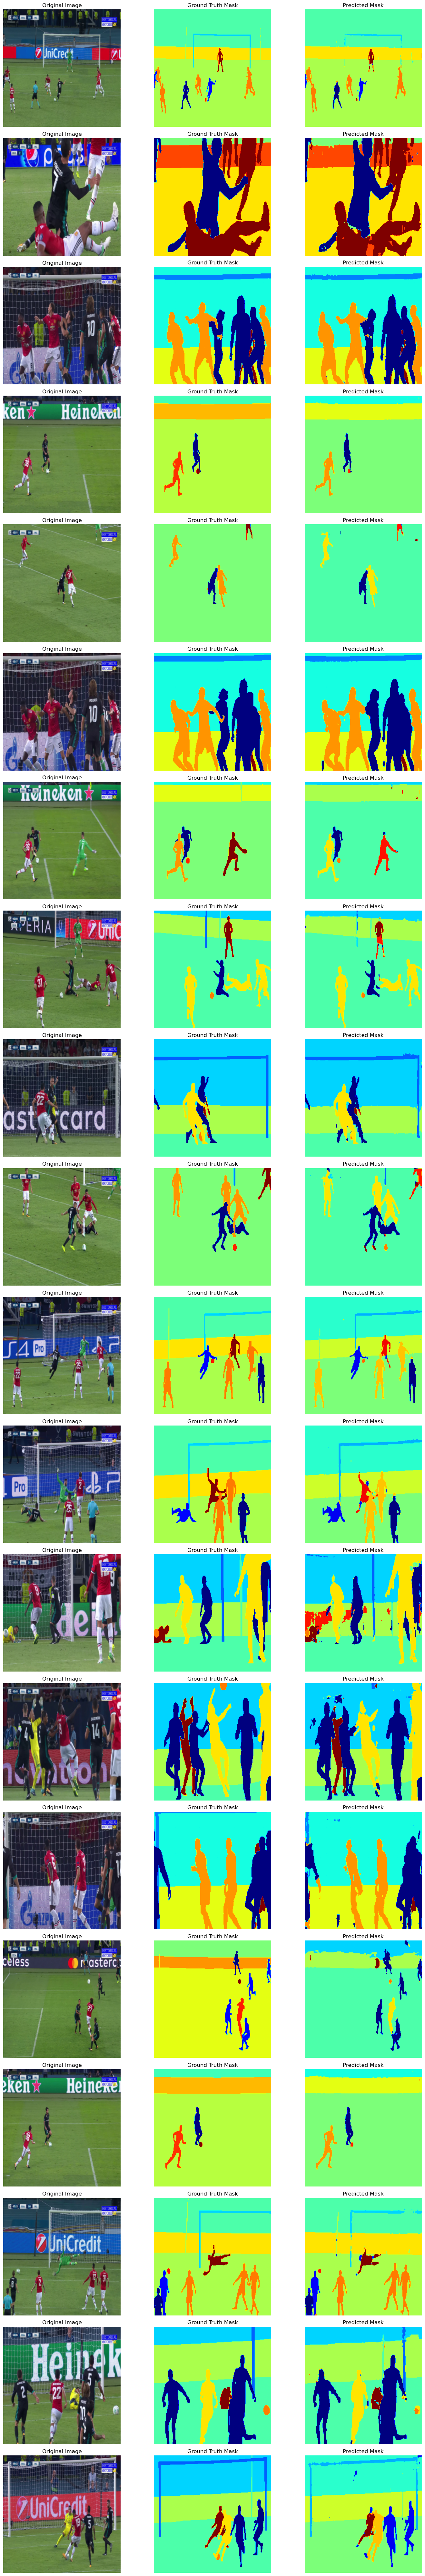

In [67]:
with torch.no_grad():
    test_iter = iter(test_loader)
    plt.figure(figsize=(15, 80))

    plot_index = 1
    for images, masks in test_iter:
        images = images.to(device)
        outputs = model(images)
        pred_masks = torch.argmax(torch.softmax(outputs, dim=1), dim=1).cpu().numpy()

        for b in range(images.size(0)):
            plt.subplot(20, 3, plot_index)
            plt.imshow(images[b].cpu().permute(1, 2, 0))
            plt.title("Original Image")
            plt.axis("off")
            plot_index += 1

            plt.subplot(20, 3, plot_index)
            plt.imshow(masks[b].cpu().numpy(), cmap="jet")
            plt.title("Ground Truth Mask")
            plt.axis("off")
            plot_index += 1

            plt.subplot(20, 3, plot_index)
            plt.imshow(pred_masks[b], cmap="jet")
            plt.title("Predicted Mask")
            plt.axis("off")
            plot_index += 1

            if plot_index > 20 * 3:  # 20개 이미지까지 시각화
                break
        if plot_index > 20 * 3:
            break

    plt.tight_layout()
    plt.show()

### *여기서부턴 순수 흥미*


image 1/1 c:\Users\\Desktop\ \ \football\images\Frame 1  (1).jpg: 384x640 6 persons, 1 handbag, 6.1ms
Speed: 1.7ms preprocess, 6.1ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)


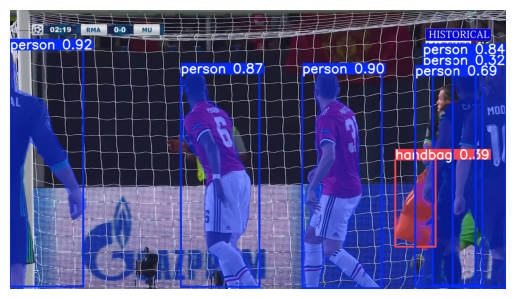

In [79]:
from ultralytics import YOLO
model = YOLO('yolov8n-seg.pt')
results = model(os.path.join(img_folder, image_files[0]))
            
img_with_masks = results[0].plot()         # 예측이 그려진 BGR 이미지 (numpy array)
# BGR -> RGB 변환
img_with_masks = cv2.cvtColor(img_with_masks, cv2.COLOR_BGR2RGB)

plt.imshow(img_with_masks)
plt.axis('off')
plt.show()

In [73]:
# Instance
print(len(results[0].masks.data))  # (각각 별도 마스크)
print(len(results[0].boxes))       # (각각 별도 바운딩박스)

7
7


In [80]:
# 결과접근
for result in results:
    # 바운딩 박스
    boxes = result.boxes.xyxy  # [x1, y1, x2, y2] 형식
    print(boxes)
    print('-'*100)
    # 마스크
    masks = result.masks.data  # 세그멘테이션 마스크
    print(masks.min(), masks.max())
    # 클래스 및 신뢰도
    classes = result.boxes.cls
    confidences = result.boxes.conf

tensor([[5.4069e-01, 1.5208e+02, 2.8382e+02, 1.0704e+03],
        [1.1313e+03, 2.4507e+02, 1.4395e+03, 1.0762e+03],
        [6.6169e+02, 2.4511e+02, 9.6562e+02, 1.0715e+03],
        [1.7137e+03, 1.7069e+02, 1.9190e+03, 1.0729e+03],
        [1.5681e+03, 2.5320e+02, 1.8027e+03, 1.0704e+03],
        [1.4911e+03, 5.7859e+02, 1.6474e+03, 9.1673e+02],
        [1.6362e+03, 2.1217e+02, 1.8283e+03, 1.0657e+03]], device='cuda:0')
----------------------------------------------------------------------------------------------------
tensor(0, device='cuda:0', dtype=torch.uint8) tensor(1, device='cuda:0', dtype=torch.uint8)


In [81]:
# 마스크와 클래스 매칭

from ultralytics import YOLO

model = YOLO('yolov8n-seg.pt')
results = model(os.path.join(img_folder, image_files[0]))

for result in results:
    # 클래스 이름 가져오기
    names = result.names  # {0: 'person', 1: 'bicycle', ...}

    # 각 검출된 객체별로 순회
    for i, (mask, box) in enumerate(zip(result.masks.data, result.boxes)):
        cls_id = int(box.cls)           # 클래스 ID (숫자)
        cls_name = names[cls_id]        # 클래스 이름
        conf = float(box.conf)          # 신뢰도

        print(f"객체 {i}: {cls_name} (ID: {cls_id}), 신뢰도: {conf:.2f}")
        print(f"마스크 shape: {mask.shape}")


image 1/1 c:\Users\\Desktop\ \ \football\images\Frame 1  (1).jpg: 384x640 6 persons, 1 handbag, 7.3ms
Speed: 2.5ms preprocess, 7.3ms inference, 2.4ms postprocess per image at shape (1, 3, 384, 640)
객체 0: person (ID: 0), 신뢰도: 0.92
마스크 shape: torch.Size([384, 640])
객체 1: person (ID: 0), 신뢰도: 0.90
마스크 shape: torch.Size([384, 640])
객체 2: person (ID: 0), 신뢰도: 0.87
마스크 shape: torch.Size([384, 640])
객체 3: person (ID: 0), 신뢰도: 0.84
마스크 shape: torch.Size([384, 640])
객체 4: person (ID: 0), 신뢰도: 0.69
마스크 shape: torch.Size([384, 640])
객체 5: handbag (ID: 26), 신뢰도: 0.39
마스크 shape: torch.Size([384, 640])
객체 6: person (ID: 0), 신뢰도: 0.32
마스크 shape: torch.Size([384, 640])


In [82]:
# 특정클래스만 필터링
for i, (mask, box) in enumerate(zip(result.masks.data, result.boxes)):
    cls_id = int(box.cls)
    cls_name = names[cls_id]

    if cls_name == 'person':  # person만 처리
        # mask는 해당 객체의 이진 마스크 (0: 배경, 1: 객체)
        person_mask = mask.cpu().numpy()

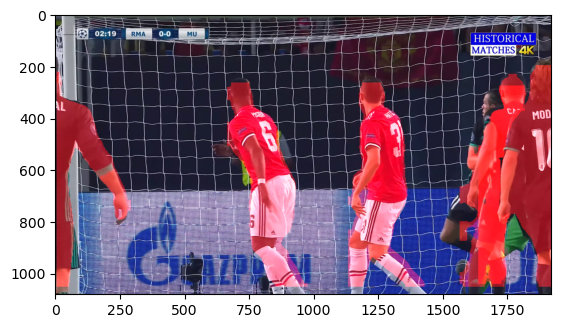

In [84]:
# 마스크 시각화, 사람영역
import cv2
import numpy as np

img = cv2.imread(os.path.join(img_folder, image_files[0]))

for i, (mask, box) in enumerate(zip(result.masks.data, result.boxes)):
    if names[int(box.cls)] == 'person':
        person_mask = mask.cpu().numpy()

        # 마스크를 원본 이미지 크기로 리사이즈
        person_mask = cv2.resize(person_mask, (img.shape[1], img.shape[0]))

        # 마스크 시각화 (빨간색 오버레이)
        colored_mask = np.zeros_like(img)
        colored_mask[person_mask > 0.5] = [0, 0, 255]  # BGR
        img = cv2.addWeighted(img, 1, colored_mask, 0.5, 0)

import matplotlib.pyplot as plt
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()

In [86]:
# 사람만 잘라내기

for i, (mask, box) in enumerate(zip(result.masks.data, result.boxes)):
    if names[int(box.cls)] == 'person':
        person_mask = mask.cpu().numpy()
        person_mask = cv2.resize(person_mask, (img.shape[1], img.shape[0]))

        # 배경 제거 (투명 PNG)
        mask_bool = person_mask > 0.5
        result_img = np.zeros((img.shape[0], img.shape[1], 4), dtype=np.uint8)
        result_img[:, :, :3] = img
        result_img[:, :, 3] = (mask_bool * 255).astype(np.uint8)

        cv2.imwrite(f'person_{i}.png', result_img)